In [3]:
from votekit.cvr_loaders import load_scottish

scottish_6_cand = load_scottish("data/scot-elex/6_cands/aberdeenshire_2012_ward9.csv")[0]
wt = scottish_6_cand.total_ballot_wt
print("number of ballots:", wt)
scottish_6_cand.df.head()

number of ballots: 4211.0


,Ranking_1,Ranking_2,Ranking_3,Ranking_4,Ranking_5,Ranking_6,Weight,Voter Set
Ballot Index,,,,,,,,
0,frozenset({Sandy Allan}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),55.0,{}
1,frozenset({Sandy Allan}),frozenset({Isobel Davidson}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),21.0,{}
2,frozenset({Sandy Allan}),frozenset({Isobel Davidson}),frozenset({Rob Merson}),frozenset({~}),frozenset({~}),frozenset({~}),4.0,{}
3,frozenset({Sandy Allan}),frozenset({Isobel Davidson}),frozenset({Rob Merson}),frozenset({Gillian Louise Owen}),frozenset({~}),frozenset({~}),1.0,{}
4,frozenset({Sandy Allan}),frozenset({Isobel Davidson}),frozenset({Rob Merson}),frozenset({Gillian Louise Owen}),frozenset({Peter Thomas Smyth}),frozenset({Richard Thomson}),2.0,{}


In [4]:
# convert back and forth to truncate at the 4th position, and turn cand names into alphanumeric
from src.conversion import profile_to_numpy_ballot_matrix, numpy_ballot_matrix_to_t_type, t_type_to_numpy_ballot_matrix, numpy_ballot_matrix_to_profile
numpy_matrix = profile_to_numpy_ballot_matrix(scottish_6_cand)
# remove the 5th column but keep the 6th (which has padding)
numpy_matrix_6_cand = numpy_matrix[:, [0,1,2,3,4,6]]
scottish_6_cand = numpy_ballot_matrix_to_profile(numpy_matrix_6_cand, 5)
scottish_6_cand.df.head()

,Ranking_1,Ranking_2,Ranking_3,Ranking_4,Ranking_5,Ranking_6,Voter Set,Weight
Ballot Index,,,,,,,,
0,frozenset({A}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),{},1.0
1,frozenset({A}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),{},1.0
2,frozenset({A}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),{},1.0
3,frozenset({A}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),{},1.0
4,frozenset({A}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),frozenset({~}),{},1.0


In [5]:
import numpy as np

# treat the loaded profile as "CVR", and noise it to create an alternative ground truth "BAL"
eta = 1/50

t_type_CVR = numpy_ballot_matrix_to_t_type(numpy_matrix_6_cand, m=6, L=5)

# shuffle it
import numpy as np
np.random.shuffle(t_type_CVR)

#noise it
t_type_BAL = np.copy(t_type_CVR)
random_indices = np.random.choice(len(t_type_CVR), size=int(len(t_type_CVR)*eta), replace=False)
for idx in random_indices:
    # replace it with a random other t_type present in the CVR
    t_type_BAL[idx] = np.random.choice(t_type_CVR)

BAL_matrix = t_type_to_numpy_ballot_matrix(t_type_BAL, m=6, L=5)
#print("noised matrix:", BAL_matrix)
noised_profile = numpy_ballot_matrix_to_profile(BAL_matrix, M=6)

from votekit.elections import FastSTV

print("Outcome under BAL:", FastSTV(noised_profile, n_seats=2).get_elected())
print("Outcome under CVR:", FastSTV(scottish_6_cand, n_seats=2).get_elected())

print("first 20 of each:")
print("BAL:", np.array(t_type_BAL[:20]).astype(int))
print("CVR:", np.array(t_type_CVR[:20]).astype(int))

Outcome under BAL: (frozenset({'C'}), frozenset({'B'}))
Outcome under CVR: (frozenset({'C'}), frozenset({'B'}))
first 20 of each:
BAL: [ 661  331  413  837  125 1115  250  578  517  609  578  131  578  578
  735  578  609  710  610 1114]
CVR: [ 661  331  413  837  125 1115  250  578  517  619  578  131  578  578
  735  578  609  710  610 1114]


In [6]:
import tqdm

winner_tuple = (frozenset({'C'}), frozenset({'A'}))

T = 1237
kappa_1 = 1
kappa_2 = 2
kappa_3 = 3

epsilon_1 = kappa_1/(T-1)
epsilon_2 = kappa_2/(T-1)
epsilon_3 = kappa_3/(T-1)

uniq, CVR_counts = np.unique(t_type_CVR, return_counts=True)
lut = np.zeros(uniq.max() + 1, dtype=int) -1
lut[uniq] = np.arange(len(uniq))
prior_mat_1 = np.zeros((len(uniq), T), dtype=float)
prior_mat_2 = np.zeros((len(uniq), T), dtype=float)
prior_mat_3 = np.zeros((len(uniq), T), dtype=float)
D_mat = np.zeros((len(uniq), T), dtype=float)
prior_mat_1 += epsilon_1
prior_mat_2 += epsilon_2
prior_mat_3 += epsilon_3

for t in uniq:
    prior_mat_1[lut[t],t] = 0
    prior_mat_2[lut[t],t] = 0
    prior_mat_3[lut[t],t] = 0

seed = 5
rng = np.random.default_rng(seed)

batch_size = 10
first_time = True
upset_probs_1 = []
upset_probs_2 = []
upset_probs_3 = []
num_discrepancies = 0
discrepancies = []

number_of_samples_per_posterior = 1000

for i in range(0, 100):
    #batch_noise_CVR = noisy_t_type_CVR_shuffled[i*batch_size : (i+1)*batch_size]
    batch_noise_CVR = t_type_BAL[i*batch_size : (i+1)*batch_size]
    batch_CVR = t_type_CVR[i*batch_size : (i+1)*batch_size]
    num_discrepancies += batch_size - np.sum(np.equal(batch_noise_CVR, batch_CVR))
    discrepancies.append(int(num_discrepancies)/(batch_size*(i+1)))

    for t_BAL, t_CVR in zip(batch_noise_CVR, batch_CVR):
        D_mat[lut[t_CVR], t_BAL] += 1

    row_wise_mass = D_mat.sum(axis=1)
    
    unobserved_CVR_per_type = CVR_counts - row_wise_mass
    upsets_1 = 0
    upsets_2 = 0
    upsets_3 = 0
    for j in tqdm.tqdm(range(number_of_samples_per_posterior)):
        list_of_dirichlet_samples_1 = [
            rng.dirichlet(prior_mat_1[k] + D_mat[k]) for k in range(prior_mat_1.shape[0])
        ]
        list_of_dirichlet_samples_2 = [
            rng.dirichlet(prior_mat_2[k] + D_mat[k]) for k in range(prior_mat_2.shape[0])
        ]
        list_of_dirichlet_samples_3 = [
            rng.dirichlet(prior_mat_3[k] + D_mat[k]) for k in range(prior_mat_3.shape[0])
        ]
        sample_matrix_1 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_1[k] for k in range(prior_mat_1.shape[0])])
        sample_matrix_2 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_2[k] for k in range(prior_mat_2.shape[0])])
        sample_matrix_3 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_3[k] for k in range(prior_mat_3.shape[0])])
        t_type_weights_1 = np.sum(sample_matrix_1 + D_mat, axis=0)
        t_type_weights_2 = np.sum(sample_matrix_2 + D_mat, axis=0)
        t_type_weights_3 = np.sum(sample_matrix_3 + D_mat, axis=0)
        uniq_t_types_1 = np.nonzero(t_type_weights_1)[0]
        uniq_t_types_2 = np.nonzero(t_type_weights_2)[0]
        uniq_t_types_3 = np.nonzero(t_type_weights_3)[0]
        numpy_profile_1 = t_type_to_numpy_ballot_matrix(uniq_t_types_1, m=6, L=5)
        numpy_profile_2 = t_type_to_numpy_ballot_matrix(uniq_t_types_2, m=6, L=5)
        numpy_profile_3 = t_type_to_numpy_ballot_matrix(uniq_t_types_3, m=6, L=5)
        votekit_profile_1 = numpy_ballot_matrix_to_profile(numpy_profile_1, M=6, wt_vec=t_type_weights_1[uniq_t_types_1])
        votekit_profile_2 = numpy_ballot_matrix_to_profile(numpy_profile_2, M=6, wt_vec=t_type_weights_2[uniq_t_types_2])
        votekit_profile_3 = numpy_ballot_matrix_to_profile(numpy_profile_3, M=6, wt_vec=t_type_weights_3[uniq_t_types_3])
        winners_1 = FastSTV(votekit_profile_1, n_seats=2).get_elected()
        winners_2 = FastSTV(votekit_profile_2, n_seats=2).get_elected()
        winners_3 = FastSTV(votekit_profile_3, n_seats=2).get_elected()
        if winners_1 != winner_tuple:
            upsets_1 += 1
        if winners_2 != winner_tuple:
            upsets_2 += 1
        if winners_3 != winner_tuple:
            upsets_3 += 1
    upset_probs_1.append(upsets_1 / number_of_samples_per_posterior)
    upset_probs_2.append(upsets_2 / number_of_samples_per_posterior)
    upset_probs_3.append(upsets_3 / number_of_samples_per_posterior)


  1%|          | 8/1000 [00:01<02:45,  5.99it/s]


KeyboardInterrupt: 

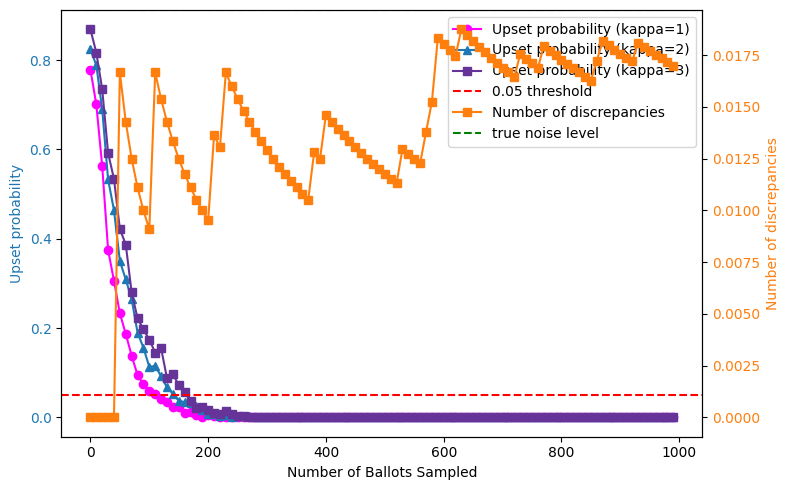

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upset_probs_1)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upset_probs_1, color="magenta", marker="o", label="Upset probability (kappa=1)")
ax_left.plot(x, upset_probs_2, color="tab:blue", marker="^", label="Upset probability (kappa=2)")
ax_left.plot(x, upset_probs_3, color="rebeccapurple", marker="s", label="Upset probability (kappa=3)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(59/2997, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

In [ ]:
wt_vec = np.array([10, 20, 30])
uniform_row = np.array([0.1, 0.2, 0.3])

posterior_sample_mat = wt_vec[:, None] * uniform_row[None, :]
posterior_sample_mat

array([[1., 2., 3.],
       [2., 4., 6.],
       [3., 6., 9.]])

In [3]:
pf = load_scottish("data/scot-elex/6_cands/aberdeenshire_2012_ward9.csv")[0]
pf.total_ballot_wt

np.float64(4818.0)

In [1]:
from src.end_to_end import e2e_synthetic_audit, e2e_synthetic_audit_multi_kappa
from votekit.cvr_loaders import load_scottish

pf = load_scottish("data/scot-elex/6_cands/aberdeenshire_2012_ward9.csv")[0]

upset_probs_by_kappa, discrepancies = e2e_synthetic_audit_multi_kappa(
    pf, m=2, kappa_list=[0.003,0.05, .3,2], seed=5, frac_ASN_max=.25
)


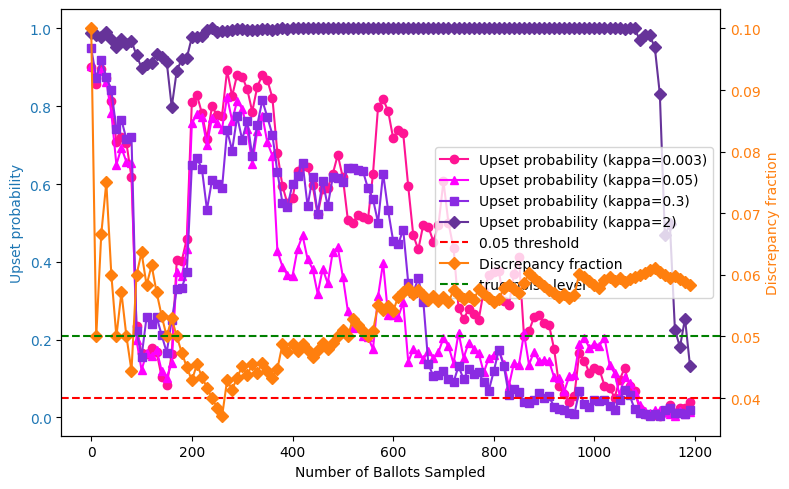

In [2]:
import matplotlib.pyplot as plt
import numpy as np

kappa_list=[.003, 0.05, .3, 2]

x = np.arange(len(discrepancies) * 10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

colors = ["deeppink", "magenta", "blueviolet", "rebeccapurple"]
markers = ["o", "^", "s", "D"]

for i, (kappa, upsets) in enumerate(zip(kappa_list, upset_probs_by_kappa)):
    ax_left.plot(
        x,
        upsets,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        label=f"Upset probability (kappa={kappa})",
    )

ax_right.plot(x, discrepancies, color="tab:orange", marker="D", label="Discrepancy fraction")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Discrepancy fraction", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()


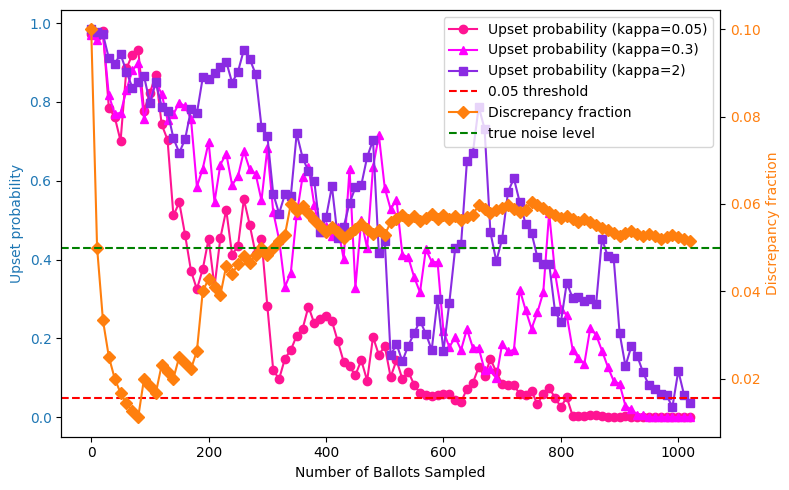

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

kappa_list=[0.05, .3, 2]

x = np.arange(len(discrepancies) * 10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

colors = ["deeppink", "magenta", "blueviolet"]
markers = ["o", "^", "s"]

for i, (kappa, upsets) in enumerate(zip(kappa_list, upset_probs_by_kappa)):
    ax_left.plot(
        x,
        upsets,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        label=f"Upset probability (kappa={kappa})",
    )

ax_right.plot(x, discrepancies, color="tab:orange", marker="D", label="Discrepancy fraction")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Discrepancy fraction", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()


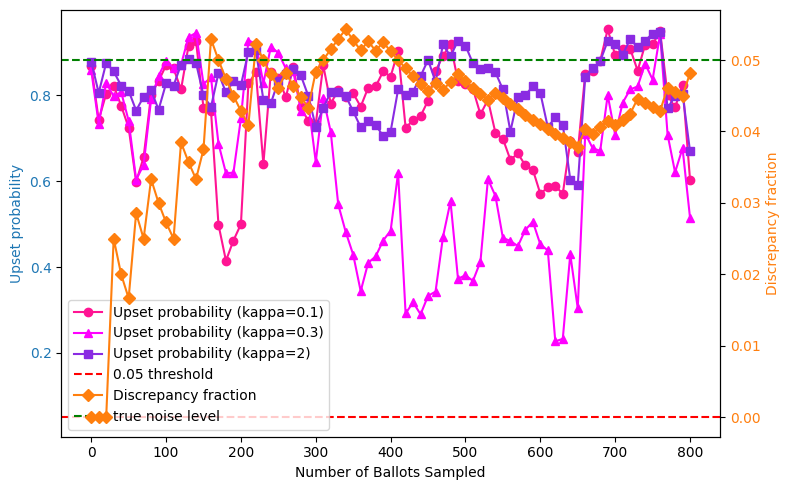

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

kappa_list=[0.1, .3, 2]

x = np.arange(len(discrepancies) * 10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

colors = ["deeppink", "magenta", "blueviolet"]
markers = ["o", "^", "s"]

for i, (kappa, upsets) in enumerate(zip(kappa_list, upset_probs_by_kappa)):
    ax_left.plot(
        x,
        upsets,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        label=f"Upset probability (kappa={kappa})",
    )

ax_right.plot(x, discrepancies, color="tab:orange", marker="D", label="Discrepancy fraction")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Discrepancy fraction", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()


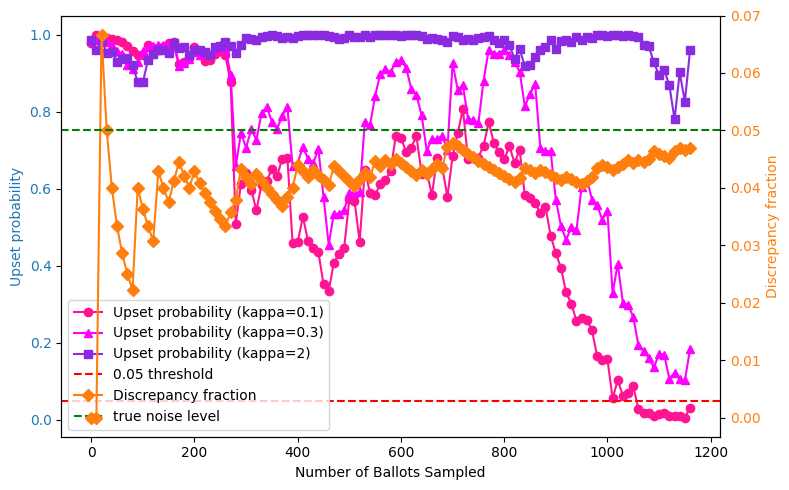

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

kappa_list=[0.1, .3, 2]

x = np.arange(len(discrepancies) * 10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

colors = ["deeppink", "magenta", "blueviolet"]
markers = ["o", "^", "s"]

for i, (kappa, upsets) in enumerate(zip(kappa_list, upset_probs_by_kappa)):
    ax_left.plot(
        x,
        upsets,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        label=f"Upset probability (kappa={kappa})",
    )

ax_right.plot(x, discrepancies, color="tab:orange", marker="D", label="Discrepancy fraction")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Discrepancy fraction", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()


In [ ]:
from src.end_to_end import e2e_synthetic_audit
from votekit.cvr_loaders import load_scottish

pf = load_scottish("data/scot-elex/6_cands/aberdeenshire_2012_ward9.csv")[0]

upsets, discrepancies = e2e_synthetic_audit(
    pf,
    m=2,
    prior_type="pessimistic",
    seed=5,
    frac_ASN_max=.25
)

Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak


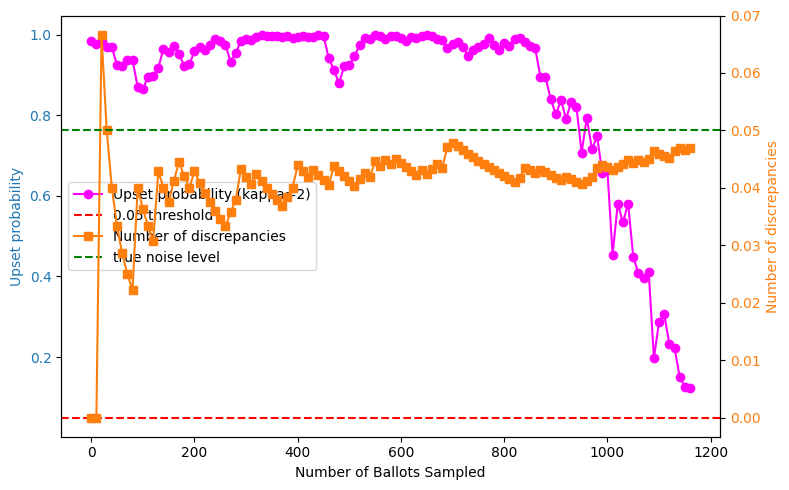

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upsets)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upsets, color="magenta", marker="o", label="Upset probability (kappa=2)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

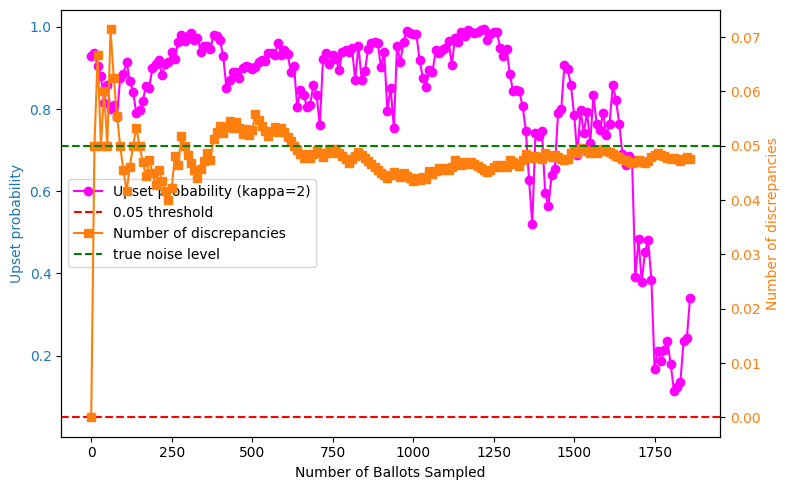

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upsets)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upsets, color="magenta", marker="o", label="Upset probability (kappa=2)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

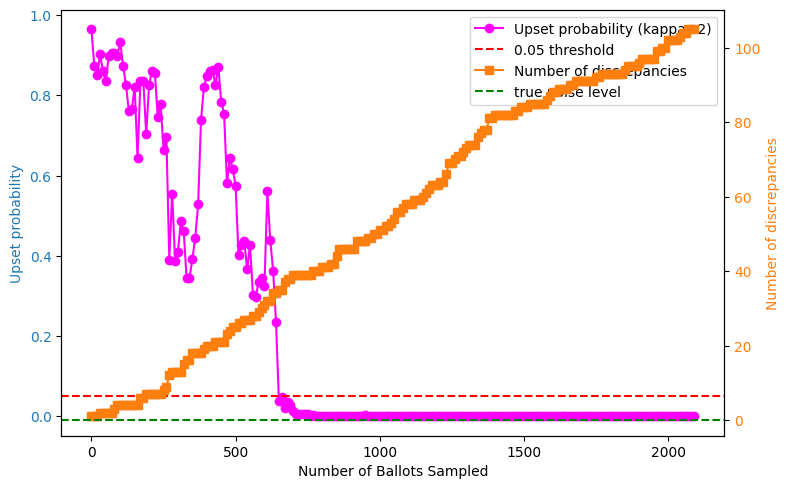

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upsets)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upsets, color="magenta", marker="o", label="Upset probability (kappa=2)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(0.05, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

In [ ]:
# Paste in one notebook cell.
# Assumes `pf` (RankProfile) and `m` (n_seats) already exist.

import numpy as np
from votekit.elections import FastSTV

from src.conversion import (
    _convert_profile_to_numpy_arrays,
    build_section_list,
    numpy_ballot_matrix_to_t_type,
    numpy_ballot_matrix_to_profile,
    _permutation_matrix_constructor,
)
from src.sampling import pivotal_sampling
from src.end_to_end import resample_posterior_rows

# Match end_to_end-style params
eta = 0.05
kappa = 2
L = None
rows_per_markov_step = 100
prior_type = "pessimistic"
seed = 5
batch_size = 100

# end_to_end currently uses global np.random for shuffle/noise and rng for Dirichlet
np.random.seed(seed)
rng = np.random.default_rng(seed)

cands = pf.candidates
M = len(cands)

# Canonical winners (optional check)
canonical_elec = FastSTV(pf, n_seats = 2, tiebreak="borda")
canonical_winners = canonical_elec.get_elected()

# 1) Convert profile -> deduplicated CVR t-types
numpy_matrix, wt_vec = _convert_profile_to_numpy_arrays(pf)
wt_vec = wt_vec.astype(int)
N = int(wt_vec.sum())
pi = (rows_per_markov_step * wt_vec / N).copy()

if L is None:
    L = M - 1
    numpy_matrix = numpy_matrix[:, [i for i in range(numpy_matrix.shape[1]) if i != numpy_matrix.shape[1] - 2]]

sections = build_section_list(M, L)
T = sections[0]
dedup_t_type_CVR = numpy_ballot_matrix_to_t_type(numpy_matrix, M, L)

CVR_lut = np.full(T, -1, dtype=np.int64)
CVR_lut[dedup_t_type_CVR] = np.arange(len(dedup_t_type_CVR))

t_type_CVR = np.repeat(dedup_t_type_CVR, wt_vec.astype(int))
np.random.shuffle(t_type_CVR)

# Make BAL t-types with eta noise (same style as end_to_end)
number_of_noised_ballots = int(N * eta)
t_type_BAL = t_type_CVR.copy()
noised_positions = np.random.choice(N, size=number_of_noised_ballots, replace=False)
t_type_BAL[noised_positions] = np.random.choice(T, size=number_of_noised_ballots, replace=True)

# Split into batches
cvr_batches = [t_type_CVR[i:i + batch_size] for i in range(0, len(t_type_CVR), batch_size)]
bal_batches = [t_type_BAL[i:i + batch_size] for i in range(0, len(t_type_BAL), batch_size)]

# 2) Build posterior structures
if prior_type == "pessimistic":
    epsilon = 1 / (T - 1)
elif prior_type == "uniform":
    epsilon = 1 / T
else:
    raise ValueError("Invalid prior type.")

uniform_row = np.zeros(T, dtype=np.float64) + epsilon
discrepancy_mat = np.zeros((len(wt_vec), T), dtype=np.int64)
posterior_sample_mat = wt_vec[:, None] * uniform_row[None, :]

uniform_row *= kappa
stacked_uniform_matrix = np.tile(uniform_row, (rows_per_markov_step, 1))

if prior_type == "pessimistic":
    for i, t_type in enumerate(dedup_t_type_CVR):
        posterior_sample_mat[i, t_type] = 0

# Use exactly one batch of size 100
batch_t_type_BAL = bal_batches[0]
batch_t_type_CVR = CVR_lut[cvr_batches[0]]

if np.any(batch_t_type_CVR == -1):
    raise ValueError("CVR lookup failed for some ballots.")

for bal, cvr in zip(batch_t_type_BAL, batch_t_type_CVR):
    discrepancy_mat[cvr, bal] += 1
    wt_vec[cvr] -= 1

uniq_sampled_rows = np.unique(batch_t_type_CVR)
posterior_sample_mat = resample_posterior_rows(
    stacked_uniform_matrix, discrepancy_mat, wt_vec, posterior_sample_mat, uniq_sampled_rows, rng
)

# One posterior draw -> sampled_t_vec
sampled_rows = pivotal_sampling(pi)
posterior_sample_mat = resample_posterior_rows(
    stacked_uniform_matrix, discrepancy_mat, wt_vec, posterior_sample_mat, sampled_rows, rng
)
sampled_t_vec = posterior_sample_mat.sum(axis=0)

print("sampled_t_vec shape:", sampled_t_vec.shape)
print("sampled_t_vec sum:", sampled_t_vec.sum())
print("sampled_t_vec (first 20):", sampled_t_vec[:20])

# 3) Initialize blank_profile exactly like end_to_end and inject sampled_t_vec
all_permutations_matrix = _permutation_matrix_constructor(M, L, sections=sections)
blank_profile = numpy_ballot_matrix_to_profile(all_permutations_matrix, M)
blank_elec = FastSTV(blank_profile, n_seats=2, tiebreak="borda")

blank_elec._data.wt_vec = sampled_t_vec
blank_elec.threshold = blank_elec._get_threshold("droop", sum(sampled_t_vec[1:]))
blank_elec.candidates = pf.candidates
blank_elec._run_and_store()
sampled_winners = blank_elec.get_elected()

print("sampled winners:", sampled_winners)
print("canonical winners:", canonical_winners)
print("upset?", sampled_winners != canonical_winners)


sampled_t_vec shape: (1237,)
sampled_t_vec sum: 4210.999999999996
sampled_t_vec (first 20): [ 1.79960747 11.54624076  1.22249191  3.87256254  5.82537912  1.41268763
  1.22550474  1.26054529  1.30753664  1.32653613  1.79417732  1.28321776
  4.71437372  1.82549147  1.6086543   1.22273366  1.22340282  1.52730912
  1.27523471  1.25504273]
Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak
Initial tiebreak was unsuccessful, performing random tiebreak
sampled winners: (frozenset({'Rob Merson'}), frozenset({'Isobel Davidson'}))
canonical winners: (frozenset({'Rob Merson'}), frozenset({'Isobel Davidson'}))
upset? False


In [ ]:
cands

('Sandy Allan',
 'Isobel Davidson',
 'Rob Merson',
 'Gillian Louise Owen',
 'Peter Thomas Smyth',
 'Richard Thomson')